# V33DA reviewer walkthrough

This notebook gives a reviewer a self-contained first look at the V33DA benchmark using the 100-event sample shipped with the repository (`data/v33da_sample/`, ~60 MB). It focuses on **visualization**: what a single event looks like across modalities, how the dataset is laid out, and how the candidate-conditioned attribution task is posed.

Full benchmark training runs against the full HF dataset (`songbirdini/V33DA`) via `scripts/train.py` — see the repository README.

In [1]:
import io
from pathlib import Path

import numpy as np
import pyarrow.parquet as pq
import soundfile as sf
import matplotlib.pyplot as plt

SAMPLE_ROOT = Path('../data/v33da_sample')
assert SAMPLE_ROOT.exists(), f'sample root missing: {SAMPLE_ROOT.resolve()}'
print('Sample root:', SAMPLE_ROOT.resolve())

Sample root: /home/songbird/code/gh_v33da/data/v33da_sample


## 1. Dataset layout and per-experiment counts

In [2]:
table = pq.read_table(SAMPLE_ROOT / 'v33da_sample.parquet')
print(f'{table.num_rows} events, {len(table.schema.names)} columns')
print()
print('Events per experiment:')
for exp, count in zip(*np.unique(table['experiment'].to_numpy(zero_copy_only=False), return_counts=True)):
    print(f'  {exp}: {count}')
print()
print('Colors per experiment (backpack codes are experiment-local):')
for exp in sorted(set(table['experiment'].to_pylist())):
    mask = np.array(table['experiment'].to_pylist()) == exp
    colors = sorted(set(np.array(table['bird_color'].to_pylist())[mask]))
    print(f'  {exp}: {colors}')

100 events, 37 columns

Events per experiment:
  juvExpBP01: 34
  juvExpBP02: 33
  juvExpBP05: 33

Colors per experiment (backpack codes are experiment-local):
  juvExpBP01: [np.str_('blue'), np.str_('peach'), np.str_('red'), np.str_('white')]
  juvExpBP02: [np.str_('blue'), np.str_('peach'), np.str_('red')]
  juvExpBP05: [np.str_('brown'), np.str_('purple'), np.str_('yellow')]


## 2. Pick one event and decode every modality

Each row embeds 3D pose, 2D keypoints, and radio telemetry as NumPy blobs. Audio, accelerometer, and video are stored as external files referenced by `*_path`.

In [3]:
EVENT_INDEX = 0  # try 0..99
event = table.slice(EVENT_INDEX, 1).to_pylist()[0]

kp3d = np.load(io.BytesIO(event['keypoints_3d']))       # (T_frames, N_birds, 5, 3) mm
kp2d_top = np.load(io.BytesIO(event['keypoints_2d_top']))  # (T_frames, N_birds, 5, 2) px
audio, sr_a = sf.read(SAMPLE_ROOT / event['audio_path'])         # (T_audio, 5) mics
accel, sr_b = sf.read(SAMPLE_ROOT / event['accelerometer_path']) # (T_audio, N_birds)
radio_pow = np.stack([np.load(io.BytesIO(event[f'radio_powR{c}'])) for c in 'ABCDM'], axis=0)

n_birds = kp3d.shape[1]
print(f"event id: {event['id']}")
print(f"  experiment: {event['experiment']}  date: {event['date']}")
print(f"  vocalizer_idx: {event['vocalizer_idx']}  (bird_color={event['bird_color']})")
print(f"  n_frames: {event['n_frames']}  n_birds: {n_birds}")
print(f"  audio: shape={audio.shape} sr={sr_a}")
print(f"  accelerometer: shape={accel.shape} sr={sr_b}")
print(f"  radio_powR* shape: {radio_pow.shape} (antenna, bird, frame)")

event id: juvExpBP01/BP_2021-08-05_08-40-49_416952_0460000/3571/b15o13_j
  experiment: juvExpBP01  date: 2021-08-05
  vocalizer_idx: 2  (bird_color=white)
  n_frames: 15  n_birds: 4
  audio: shape=(6641, 5) sr=24414
  accelerometer: shape=(6641, 4) sr=24414
  radio_powR* shape: (5, 4, 15) (antenna, bird, frame)


## 3. 5-channel cage microphones

The five cage microphones share a fixed 3D layout (rear, left, door, right, ceiling). The vocalization appears on every channel with channel-specific delays and amplitudes.

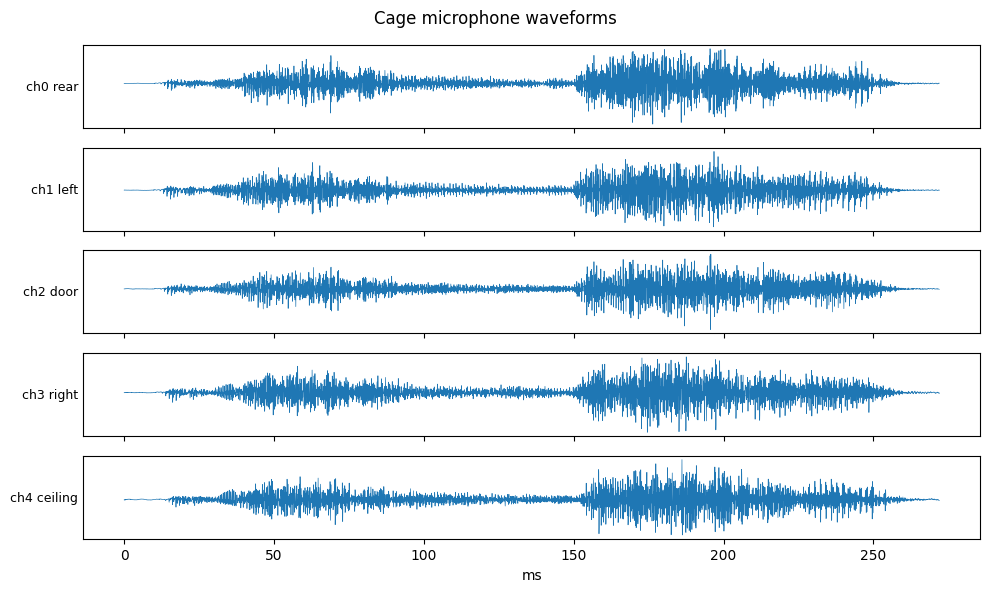

In [4]:
fig, axes = plt.subplots(5, 1, figsize=(10, 6), sharex=True)
mic_labels = ['ch0 rear', 'ch1 left', 'ch2 door', 'ch3 right', 'ch4 ceiling']
t = np.arange(audio.shape[0]) / sr_a * 1000
for i, ax in enumerate(axes):
    ax.plot(t, audio[:, i], linewidth=0.5)
    ax.set_ylabel(mic_labels[i], rotation=0, ha='right', va='center', fontsize=9)
    ax.set_yticks([])
axes[-1].set_xlabel('ms')
fig.suptitle('Cage microphone waveforms')
fig.tight_layout()
plt.show()

## 4. Accelerometer per bird — the oracle signal

The on-body vibration channel lights up only on the bird that is actually vocalizing. This is the verification channel used to label the dataset and is **withheld from every non-oracle model**.

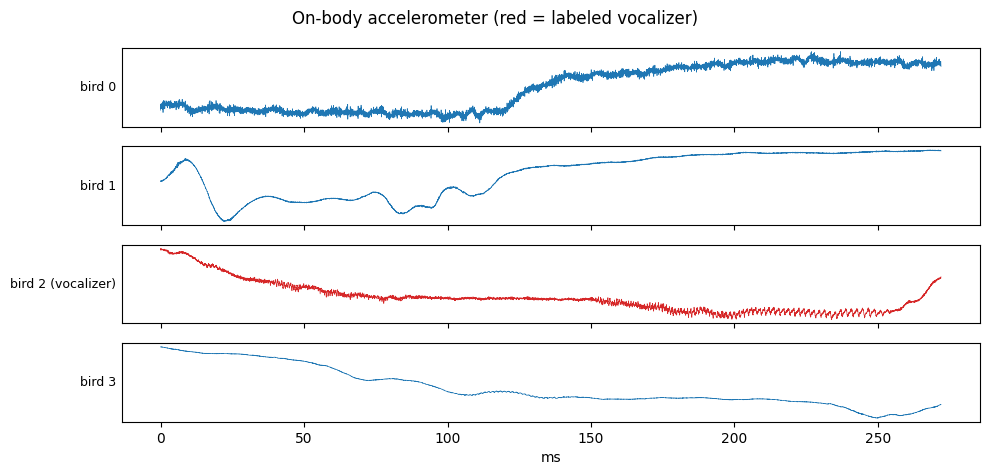

In [5]:
fig, axes = plt.subplots(n_birds, 1, figsize=(10, 1.2 * n_birds), sharex=True)
if n_birds == 1:
    axes = [axes]
t_acc = np.arange(accel.shape[0]) / sr_b * 1000
for b in range(n_birds):
    is_vocalizer = (b == event['vocalizer_idx'])
    label = f'bird {b}' + (' (vocalizer)' if is_vocalizer else '')
    axes[b].plot(t_acc, accel[:, b], color='C3' if is_vocalizer else 'C0', linewidth=0.5)
    axes[b].set_ylabel(label, rotation=0, ha='right', va='center', fontsize=9)
    axes[b].set_yticks([])
axes[-1].set_xlabel('ms')
fig.suptitle('On-body accelerometer (red = labeled vocalizer)')
fig.tight_layout()
plt.show()

## 5. 3D pose — where every candidate was at the moment of the call

Candidate-conditioned attribution depends on 3D pose. The keypoint order is `[beak, head, backpack, tail base, tail tip]`.

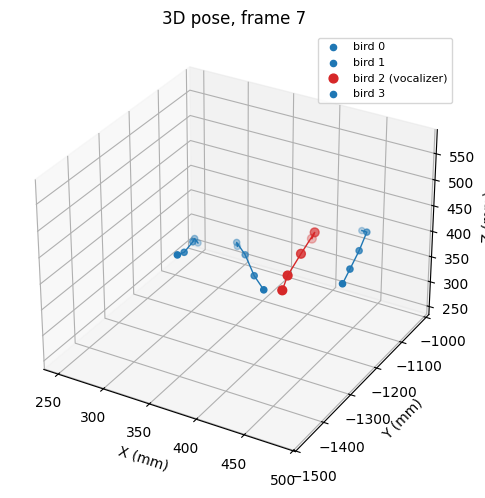

In [6]:
mid_frame = kp3d.shape[0] // 2
kp_frame = kp3d[mid_frame]  # (N_birds, 5, 3)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
for b in range(n_birds):
    xyz = kp_frame[b]
    is_vocalizer = (b == event['vocalizer_idx'])
    ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2],
               c='C3' if is_vocalizer else 'C0',
               s=40 if is_vocalizer else 20,
               label=f'bird {b}' + (' (vocalizer)' if is_vocalizer else ''))
    ax.plot(xyz[:, 0], xyz[:, 1], xyz[:, 2],
            color='C3' if is_vocalizer else 'C0', linewidth=1)
ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
ax.set_zlabel('Z (mm)')
ax.set_title(f'3D pose, frame {mid_frame}')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Radio telemetry

Each bird carries an FM transmitter. The four receiver antennas (A–D) produce per-bird received-power time series at video frame rate (47.68 Hz).

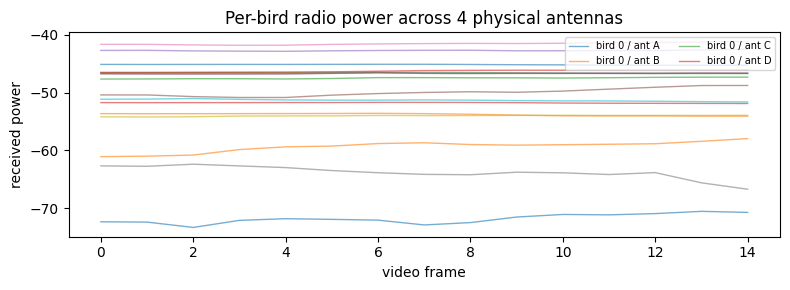

In [7]:
fig, ax = plt.subplots(figsize=(8, 3))
frames = np.arange(radio_pow.shape[2])
antenna_labels = list('ABCDM')
for b in range(n_birds):
    for a_idx in range(4):
        ax.plot(frames, radio_pow[a_idx, b, :], alpha=0.6, linewidth=1,
                label=f'bird {b} / ant {antenna_labels[a_idx]}' if b == 0 else None)
ax.set_xlabel('video frame')
ax.set_ylabel('received power')
ax.set_title('Per-bird radio power across 4 physical antennas')
ax.legend(fontsize=7, ncol=2, loc='upper right')
plt.tight_layout()
plt.show()

## 7. Next steps

- The full dataset lives at [`songbirdini/V33DA`](https://huggingface.co/datasets/songbirdini/V33DA) on Hugging Face; the `songbirdini/v33da_pp` companion release adds overlap-filtered and longer-context buckets.
- Training every baseline family from the paper is a single command once the full dataset is downloaded (see the repository README and `scripts/train.py`).
- The three evaluation regimes (session-disjoint, held-out experiment, leave-one-bird-out) are generated by `scripts/prepare_v33da_splits.py`.